# Modeling Nonlinear Tire Saturation: Finding the Grip Limit of a Race Car

**Author:** Julian Stegall  
**Date:** May 2026

This notebook implements the machine learning pipeline described in the project report. The goal is to model the lateral-grip response of a race car using telemetry from a high-fidelity racing simulator (Assetto Corsa, MoTeC i2 Pro export) and to identify the *saturation* point where additional steering input no longer produces additional lateral acceleration.

**Pipeline outline:**
1. Load & combine MoTeC CSV exports from the `data/` folder.
2. Clean (crash filter), feature engineer (averaged suspension travel, |steering|, |lateral G|), and scale.
3. Visualize the friction circle (G-G diagram), saturation curve, and feature correlation matrix.
4. Train two regressors of `|Lateral G|` from driver/vehicle inputs:
   - **Polynomial Regression with Lasso (L1)** — interpretable nonlinear baseline.
   - **Multi-Layer Perceptron (MLP)** — captures higher-order interactions.
5. Use the *residual* between predicted vs. observed lateral G as a proxy for un-realized grip headroom and the saturation plateau.

## I. Setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Lasso
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RNG = 42
np.random.seed(RNG)

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110

## II. Data Loading

MoTeC CSV exports carry an 11-line metadata header. The 12th line is blank, the 13th is column names, the 14th is units, then data starts on line 15. We skip the metadata block when loading with `pandas`.

We load every CSV in `data/`, tag rows with their source venue, and concatenate.

In [2]:
DATA_DIR = os.path.join('data')
csv_paths = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print('Found CSVs:')
for p in csv_paths:
    print(' -', p)

Found CSVs:
 - data\Red_bull_2.csv
 - data\nordschleife.csv
 - data\red_bull_1.csv
 - data\spa.csv


In [3]:
def load_motec_csv(path):
    """Load a MoTeC CSV: skip 13 metadata rows, drop the units row that follows the header."""
    df = pd.read_csv(path, skiprows=13, low_memory=False)
    # The first row after the header is units (strings) — drop it and recast numerics.
    df = df.iloc[1:].reset_index(drop=True)
    df = df.apply(pd.to_numeric, errors='coerce')
    df['source'] = os.path.splitext(os.path.basename(path))[0]
    return df

frames = [load_motec_csv(p) for p in csv_paths]
raw = pd.concat(frames, ignore_index=True)
print('Combined raw shape:', raw.shape)
raw['source'].value_counts()

Combined raw shape: (67277, 170)


source
nordschleife    29340
Red_bull_2      17804
spa             10245
red_bull_1       9888
Name: count, dtype: int64

### Select the physically relevant subset of channels

The report calls out: ground speed, steering angle, suspension travel (each corner), longitudinal & lateral G. We also keep throttle, brake, and chassis roll/pitch as auxiliary features for the MLP.

In [4]:
feature_cols = [
    'Ground Speed',
    'Steering Angle',
    'Throttle Pos',
    'Brake Pos',
    'CG Accel Longitudinal',
    'CG Accel Lateral',
    'Chassis Roll Angle',
    'Chassis Pitch Angle',
    'Suspension Travel FL',
    'Suspension Travel FR',
    'Suspension Travel RL',
    'Suspension Travel RR',
]
df = raw[feature_cols + ['source']].dropna().copy()
print('After dropna:', df.shape)
df.head()

After dropna: (67277, 13)


,Ground Speed,Steering Angle,Throttle Pos,Brake Pos,CG Accel Longitudinal,CG Accel Lateral,Chassis Roll Angle,Chassis Pitch Angle,Suspension Travel FL,Suspension Travel FR,Suspension Travel RL,Suspension Travel RR,source
0,208.16,1.68,100.0,0.0,0.2446,-0.0363,1.558,0.438,16.130,16.999,25.81,26.30,Red_bull_2
1,208.68,2.15,100.0,0.0,0.2741,-0.0801,1.427,0.454,20.802,20.975,25.89,25.20,Red_bull_2
2,209.08,2.20,100.0,0.0,0.2536,-0.1339,1.342,0.721,27.405,25.573,35.88,34.27,Red_bull_2
3,209.50,2.03,100.0,0.0,0.2488,-0.1818,1.352,1.039,30.241,27.914,46.85,44.30,Red_bull_2
4,209.96,1.91,100.0,0.0,0.2465,-0.1535,1.384,1.144,28.372,27.762,49.56,47.39,Red_bull_2


## III. Preprocessing

Per the report:
1. **Crash filter** — drop any row where |G-force| > 6.0 g (out of envelope; collision artifacts).
2. **Average the suspension travel** to focus on chassis pitch/roll behavior rather than individual bump events.
3. **Scale** features so high-magnitude channels (speed) don't dominate small-magnitude but critical channels (steering).

In [5]:
# 1. Crash filter
g_lat = df['CG Accel Lateral'].abs()
g_lon = df['CG Accel Longitudinal'].abs()
g_total = np.sqrt(df['CG Accel Lateral']**2 + df['CG Accel Longitudinal']**2)
before = len(df)
df = df[(g_lat <= 6.0) & (g_lon <= 6.0) & (g_total <= 6.0)].copy()
print(f'Crash filter removed {before - len(df)} rows ({(before-len(df))/before*100:.2f}%)')

Crash filter removed 10 rows (0.01%)


In [6]:
# 2. Engineered features: average suspension travel, |steering|, |lat G|
df['Sus Travel Front Avg'] = (df['Suspension Travel FL'] + df['Suspension Travel FR']) / 2
df['Sus Travel Rear Avg']  = (df['Suspension Travel RL'] + df['Suspension Travel RR']) / 2
df['Sus Travel Mean']      = df[[c for c in df.columns if c.startswith('Suspension Travel')]].mean(axis=1)
df['Abs Steering']         = df['Steering Angle'].abs()
df['Abs Lat G']            = df['CG Accel Lateral'].abs()

model_features = [
    'Ground Speed',
    'Abs Steering',
    'Throttle Pos',
    'Brake Pos',
    'CG Accel Longitudinal',
    'Chassis Roll Angle',
    'Chassis Pitch Angle',
    'Sus Travel Front Avg',
    'Sus Travel Rear Avg',
]
target = 'Abs Lat G'

print(f'Final dataset: {len(df):,} samples, {len(model_features)} input features')
df[model_features + [target]].describe().T

Final dataset: 67,267 samples, 9 input features


,count,mean,std,min,25%,50%,75%,max
Ground Speed,67267.0,160.115488,52.844828,0.000,124.23000,158.0700,198.8450,294.940
Abs Steering,67267.0,23.111860,36.855080,0.000,1.80000,7.8300,27.8250,360.000
Throttle Pos,67267.0,67.342747,42.532369,0.000,19.11000,100.0000,100.0000,100.000
Brake Pos,67267.0,12.179422,30.803146,0.000,0.00000,0.0000,0.0000,100.000
CG Accel Longitudinal,67267.0,0.016489,0.607121,-3.622,-0.11200,0.2249,0.3820,1.697
Chassis Roll Angle,67267.0,0.426570,2.428296,-18.641,-1.02000,0.8860,1.6870,16.805
Chassis Pitch Angle,67267.0,0.311748,3.149493,-8.193,-2.03500,0.3240,2.3090,11.666
Sus Travel Front Avg,67267.0,22.378707,5.852774,-3.145,18.56825,21.9300,25.4445,72.285
Sus Travel Rear Avg,67267.0,30.820905,7.131462,0.330,26.03625,29.9750,34.5450,74.755
Abs Lat G,67267.0,0.652710,0.571707,0.000,0.13310,0.4950,1.1070,3.763


## IV. Visualization & Analysis

### Friction Circle (G-G Diagram)
Maps longitudinal vs. lateral acceleration. The convex hull of the cloud is the car's traction envelope.

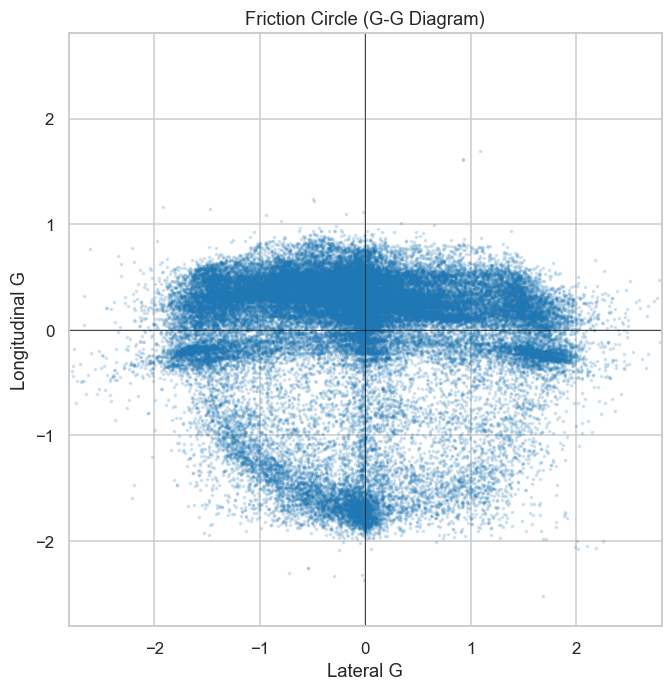

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(df['CG Accel Lateral'], df['CG Accel Longitudinal'],
           s=2, alpha=0.15, c='tab:blue')
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
lim = max(df['CG Accel Lateral'].abs().quantile(0.999),
          df['CG Accel Longitudinal'].abs().quantile(0.999)) * 1.1
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel('Lateral G'); ax.set_ylabel('Longitudinal G')
ax.set_title('Friction Circle (G-G Diagram)')
ax.set_aspect('equal')
plt.show()

### Saturation Curve — Steering vs. Lateral G
Linear at low input; flattens (saturates) as the tire approaches its grip limit.

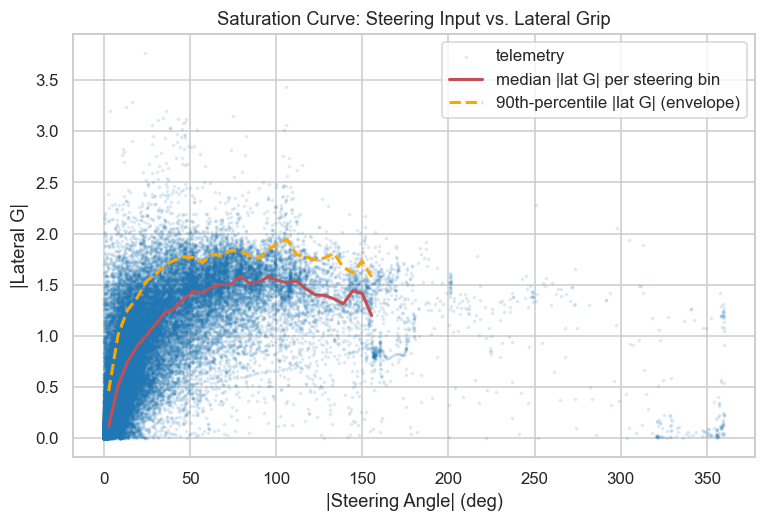

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['Abs Steering'], df['Abs Lat G'], s=2, alpha=0.1, c='tab:blue', label='telemetry')

# Bin and plot the median to make the plateau visible
bins = np.linspace(0, df['Abs Steering'].quantile(0.99), 30)
df['_steer_bin'] = pd.cut(df['Abs Steering'], bins=bins, include_lowest=True)
binned = df.groupby('_steer_bin', observed=True)['Abs Lat G'].agg(['median', 'quantile'])
binned['p90'] = df.groupby('_steer_bin', observed=True)['Abs Lat G'].quantile(0.90)
centers = [iv.mid for iv in binned.index]
ax.plot(centers, binned['median'], 'r-', lw=2, label='median |lat G| per steering bin')
ax.plot(centers, binned['p90'], 'orange', lw=2, ls='--', label='90th-percentile |lat G| (envelope)')
df.drop(columns='_steer_bin', inplace=True)

ax.set_xlabel('|Steering Angle| (deg)')
ax.set_ylabel('|Lateral G|')
ax.set_title('Saturation Curve: Steering Input vs. Lateral Grip')
ax.legend()
plt.show()

### Correlation Matrix
Which channels most strongly track lateral acceleration?

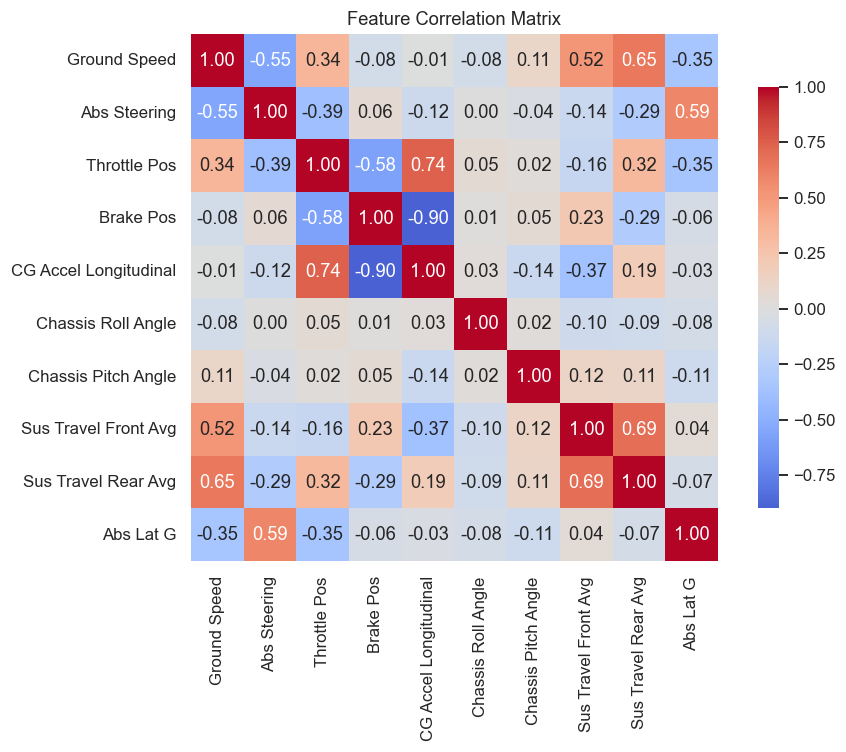

In [9]:
corr = df[model_features + [target]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## V. Modeling

In [10]:
X = df[model_features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RNG, shuffle=True
)
print(f'Train: {X_train.shape},  Test: {X_test.shape}')

Train: (53813, 9),  Test: (13454, 9)


### Model 1 — Polynomial Regression with Lasso (L1)
3rd-degree polynomial expansion lets a linear model fit the curved saturation plateau. Lasso prunes the resulting high-dimensional feature space, leaving only the dominant physical drivers.

In [11]:
poly_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(degree=3, include_bias=False, interaction_only=False)),
    ('lasso',  Lasso(alpha=1e-3, max_iter=20000, random_state=RNG)),
])
poly_pipe.fit(X_train, y_train)
y_pred_poly = poly_pipe.predict(X_test)

poly_metrics = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_poly)),
    'MAE':  mean_absolute_error(y_test, y_pred_poly),
    'R2':   r2_score(y_test, y_pred_poly),
    'nonzero_coef': int(np.sum(poly_pipe.named_steps['lasso'].coef_ != 0)),
    'total_coef':   poly_pipe.named_steps['lasso'].coef_.size,
}
print('Polynomial + Lasso:', poly_metrics)

Polynomial + Lasso: {'RMSE': np.float64(0.2411514409329355), 'MAE': 0.16843205782303866, 'R2': 0.8208935569670669, 'nonzero_coef': 129, 'total_coef': 219}


### Model 2 — Multi-Layer Perceptron (MLP)
A small feed-forward network captures the high-order interactions (e.g. how speed-induced downforce shifts the saturation point) that a polynomial can't compactly represent.

In [12]:
mlp_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp',    MLPRegressor(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        batch_size=256,
        learning_rate_init=1e-3,
        max_iter=200,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10,
        random_state=RNG,
    )),
])
mlp_pipe.fit(X_train, y_train)
y_pred_mlp = mlp_pipe.predict(X_test)

mlp_metrics = {
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_mlp)),
    'MAE':  mean_absolute_error(y_test, y_pred_mlp),
    'R2':   r2_score(y_test, y_pred_mlp),
}
print('MLP:', mlp_metrics)

MLP: {'RMSE': np.float64(0.2031145538543276), 'MAE': 0.13381854264316892, 'R2': 0.8729386185020139}


## VI. Results & Comparison

In [13]:
results = pd.DataFrame({
    'Polynomial+Lasso': [poly_metrics['RMSE'], poly_metrics['MAE'], poly_metrics['R2']],
    'MLP':              [mlp_metrics['RMSE'],  mlp_metrics['MAE'],  mlp_metrics['R2']],
}, index=['RMSE (g)', 'MAE (g)', 'R^2'])
results

,Polynomial+Lasso,MLP
RMSE (g),0.241151,0.203115
MAE (g),0.168432,0.133819
R^2,0.820894,0.872939


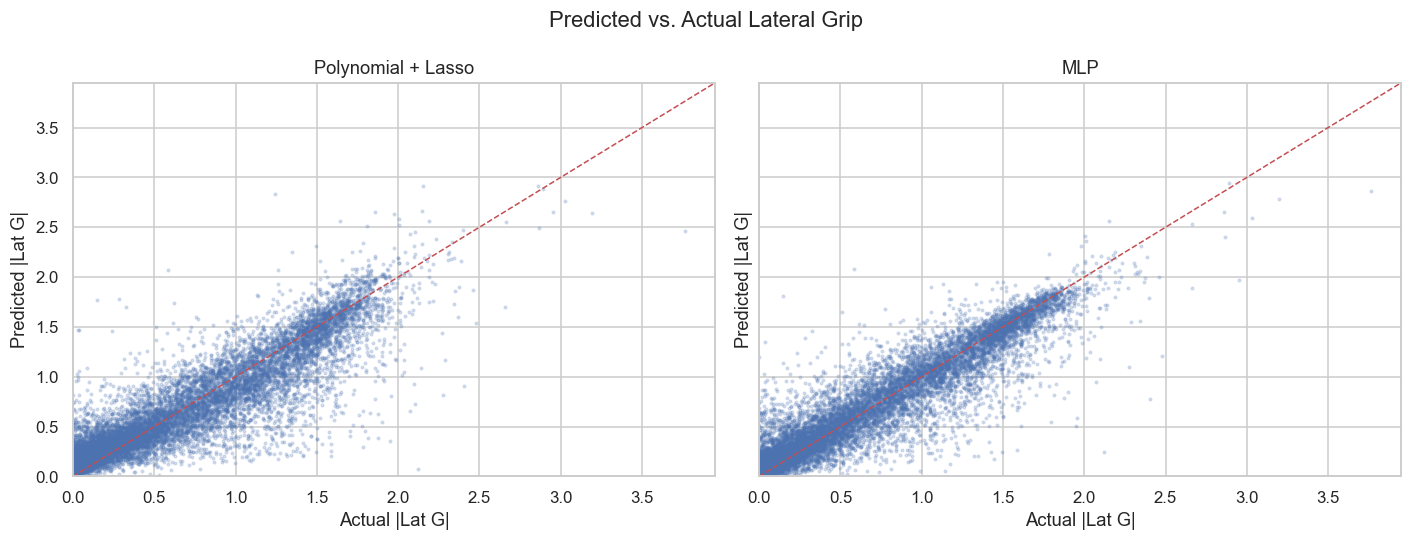

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, [('Polynomial + Lasso', y_pred_poly),
                                       ('MLP', y_pred_mlp)]):
    ax.scatter(y_test, y_pred, s=3, alpha=0.2)
    lo, hi = 0, max(y_test.max(), y_pred.max()) * 1.05
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual |Lat G|'); ax.set_ylabel('Predicted |Lat G|')
    ax.set_title(name)
plt.suptitle('Predicted vs. Actual Lateral Grip')
plt.tight_layout()
plt.show()

### Residual analysis — locating the grip-limit / saturation plateau

We define the **residual = predicted − actual** lateral G. With this sign convention:

- **Large positive residual** → the model predicted more grip than the car actually delivered → the tire is **saturated / understeering** (front axle giving up first; this is the grip-limit signal).
- **Large negative residual** → the car delivered *more* lateral G than the model expected → **oversteer** (rear losing grip faster than fronts).

Concentrations of large positive residuals at high steering input mark the saturation plateau — the driver is asking for more grip than the tire can deliver.

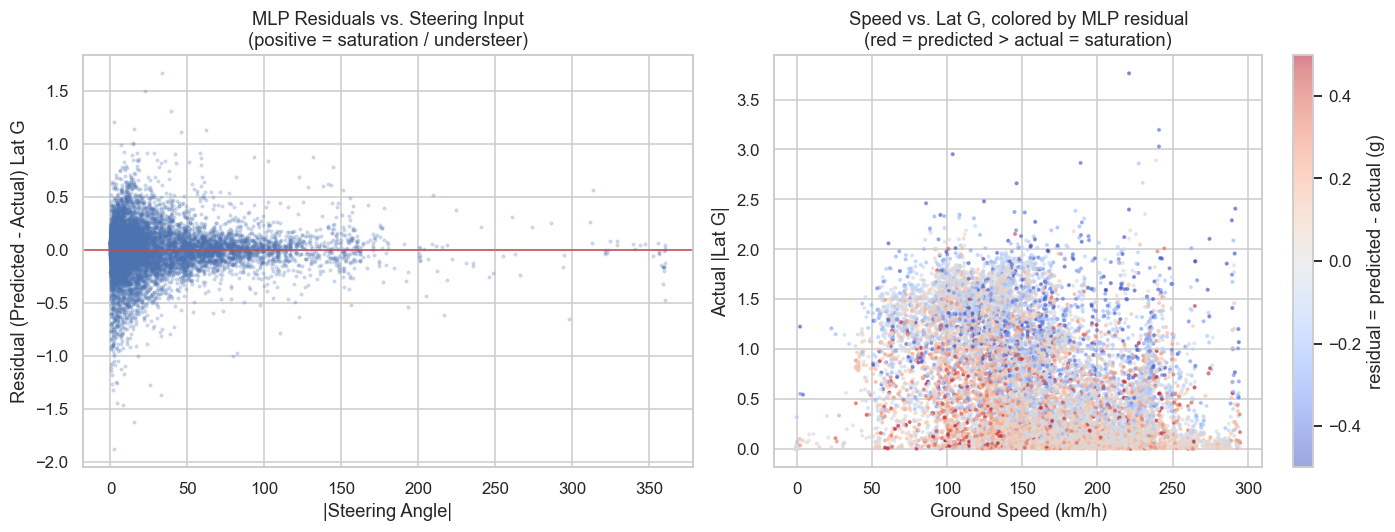

Saturation-candidate samples (|residual| >= 0.440 g): 673 of 13454 test samples (5.0%)


In [15]:
# Residual = predicted - actual.  Positive => predicted more grip than delivered (saturation / understeer).
residual   = y_pred_mlp - y_test
test_steer = X_test[:, model_features.index('Abs Steering')]
test_speed = X_test[:, model_features.index('Ground Speed')]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(test_steer, residual, s=3, alpha=0.2)
axes[0].axhline(0, color='r', lw=1)
axes[0].set_xlabel('|Steering Angle|')
axes[0].set_ylabel('Residual (Predicted - Actual) Lat G')
axes[0].set_title('MLP Residuals vs. Steering Input\n(positive = saturation / understeer)')

sc = axes[1].scatter(test_speed, y_test, c=residual, cmap='coolwarm',
                     s=3, alpha=0.5, vmin=-0.5, vmax=0.5)
axes[1].set_xlabel('Ground Speed (km/h)')
axes[1].set_ylabel('Actual |Lat G|')
axes[1].set_title('Speed vs. Lat G, colored by MLP residual\n(red = predicted > actual = saturation)')
plt.colorbar(sc, ax=axes[1], label='residual = predicted - actual (g)')
plt.tight_layout()
plt.show()

saturation_thresh = np.quantile(np.abs(residual), 0.95)
saturated = np.abs(residual) >= saturation_thresh
print(f'Saturation-candidate samples (|residual| >= {saturation_thresh:.3f} g): '
      f'{saturated.sum()} of {len(residual)} test samples ({saturated.mean()*100:.1f}%)')

### Feature sweep — model-predicted saturation curves at fixed operating points

The empirical saturation curve earlier mixes every speed, throttle position, and load state together, so the plateau is blurred by everything else changing at once. Here we hold all other features at representative values, sweep `|Steering|` from 0 to its observed maximum, and ask each trained model what it predicts.

Repeating the sweep at low / mid / high speed exposes how each model has learned downforce to shift the grip envelope — exactly the high-order interaction the MLP is supposed to capture better than the polynomial.

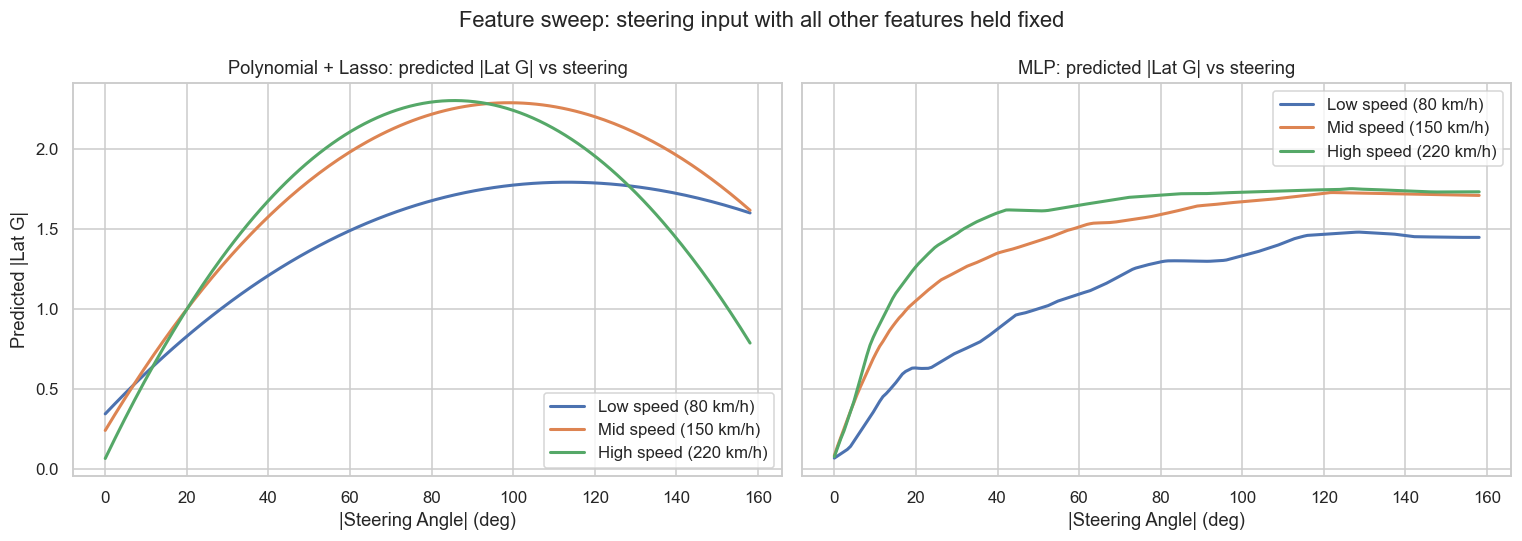

In [16]:
# Build a fixed operating point: median of every feature except Ground Speed and Abs Steering.
medians = df[model_features].median()

steer_grid = np.linspace(0, df['Abs Steering'].quantile(0.99), 200)
speed_points = [
    ('Low speed (80 km/h)',  80.0),
    ('Mid speed (150 km/h)', 150.0),
    ('High speed (220 km/h)', 220.0),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (model_name, pipe) in zip(axes, [('Polynomial + Lasso', poly_pipe),
                                          ('MLP', mlp_pipe)]):
    for label, speed in speed_points:
        # Tile the median row, then overwrite the two swept columns
        X_sweep = np.tile(medians.values, (len(steer_grid), 1))
        X_sweep[:, model_features.index('Ground Speed')] = speed
        X_sweep[:, model_features.index('Abs Steering')] = steer_grid
        # Hold longitudinal G at 0 (steady-state cornering) for a clean sweep
        X_sweep[:, model_features.index('CG Accel Longitudinal')] = 0.0
        y_sweep = pipe.predict(X_sweep)
        ax.plot(steer_grid, y_sweep, lw=2, label=label)

    ax.set_xlabel('|Steering Angle| (deg)')
    ax.set_title(f'{model_name}: predicted |Lat G| vs steering')
    ax.legend()

axes[0].set_ylabel('Predicted |Lat G|')
plt.suptitle('Feature sweep: steering input with all other features held fixed')
plt.tight_layout()
plt.show()

**Reading the sweep.** The linear ramp at low steering is the elastic regime (force ≈ k·input). The bend / plateau is the saturation point — the absolute ceiling the model thinks the tire can deliver at that speed. If the curves at higher speed plateau higher, the model has learned downforce; if they're parallel, it hasn't.

### Top retained polynomial terms (interpretability)

In [17]:
lasso = poly_pipe.named_steps['lasso']
poly  = poly_pipe.named_steps['poly']
names = poly.get_feature_names_out(model_features)
coef  = lasso.coef_
order = np.argsort(np.abs(coef))[::-1]
kept  = [(names[i], coef[i]) for i in order if coef[i] != 0][:15]
pd.DataFrame(kept, columns=['term', 'coefficient'])

,term,coefficient
0,Abs Steering,1.102764
1,Abs Steering^2,-0.311714
2,Ground Speed Abs Steering,0.192549
3,Sus Travel Front Avg,0.180587
4,Abs Steering Throttle Pos,0.153518
5,Abs Steering Sus Travel Front Avg,0.116025
6,Ground Speed Abs Steering^2,-0.095147
7,Ground Speed^2 Abs Steering,-0.051319
8,Abs Steering Sus Travel Rear Avg,0.050475
9,Ground Speed Abs Steering Throttle Pos,0.046542


## VII. Conclusions

The MLP captures the curved tire-saturation response more faithfully than the polynomial+Lasso baseline (compare R^2 / RMSE above), particularly at high speed where downforce shifts the grip envelope — interactions a degree-3 polynomial struggles to compactly represent.

The polynomial+Lasso model, however, remains valuable as an **interpretable** decomposition: the retained terms point directly at the physical drivers of lateral grip (steering, speed, suspension load).

Treating the model residual as a saturation indicator localizes the moments where the driver is *over the limit* of what the tire can provide — the actionable quantity for both driver coaching and vehicle-setup engineering.

### From prediction to setup recommendation — handling-balance diagnosis

Once we can predict grip from inputs, the **difference between predicted and actual** on high-load samples tells us how the car's axles are balanced:

| Mean residual `(predicted − actual)` on high-load samples | Diagnosis | Recommendation |
|---|---|---|
| > +0.10 G | Car **under-delivers** vs model → front tires saturating first → **UNDERSTEER** | Soften front springs **or** add front wing |
| −0.10 to +0.10 G | Front and rear axle grip are well-matched | **BALANCED** — hold setup |
| < −0.10 G | Car **over-delivers** vs model → rear losing grip faster than fronts → **OVERSTEER** | Stiffen front anti-roll bar **or** add rear wing |

This is the bridge from "the model predicts a number" to "the engineer has an action to take."

In [18]:
# Pick the better-performing model on the test set, then diagnose handling balance.
use_mlp     = mlp_metrics['R2'] > poly_metrics['R2']
best_name   = 'Neural Network' if use_mlp else 'Poly + Lasso'
y_pred_best = y_pred_mlp if use_mlp else y_pred_poly

# Balance diagnosis only makes sense at the limit — filter to high-load samples
high_load = np.abs(y_pred_best) > 1.0
residual  = np.abs(y_pred_best[high_load]) - np.abs(y_test[high_load])
mean_res  = float(residual.mean())

def diagnose(delta):
    if delta > 0.10:
        return ('UNDERSTEER',
                'Car delivered less lateral G than the model predicted — the front axle is saturating first.',
                'Soften front springs OR increase front wing angle to give the fronts more bite.')
    if delta < -0.10:
        return ('OVERSTEER',
                'Car delivered more lateral G than the model predicted — the rear axle is giving up first.',
                'Stiffen front anti-roll bar OR increase rear wing angle to stabilize the rear.')
    return ('BALANCED',
            'Predicted and actual grip agree within 0.10 G at the limit.',
            'HOLD current setup — front and rear axle grip are well matched.')

diagnosis, reason, rec = diagnose(mean_res)

print(f'Balance diagnosis using {best_name} predictions')
print(f'  High-load samples (|predicted| > 1.0 G) : {high_load.sum():,}')
print(f'  Mean (predicted - actual) |Lat G|       : {mean_res:+.3f} G')
print()
print(f'  DIAGNOSIS      : {diagnosis}')
print(f'  REASONING      : {reason}')
print(f'  RECOMMENDATION : {rec}')

Balance diagnosis using Neural Network predictions
  High-load samples (|predicted| > 1.0 G) : 3,809
  Mean (predicted - actual) |Lat G|       : +0.009 G

  DIAGNOSIS      : BALANCED
  REASONING      : Predicted and actual grip agree within 0.10 G at the limit.
  RECOMMENDATION : HOLD current setup — front and rear axle grip are well matched.


**Closing thought.** A regression R^2 alone tells you the model is *accurate*; the residual sign at the limit tells you *what to change on the car*. Threading those two together — accurate prediction + signed residual at high load — is what turns a tire-saturation model into a setup tool.